<h1 style="font-family:verdana;"> <center>Diabetes prediction ML</center> </h1>
<p><center style="color:#159364; font-family:cursive;">Pouya Shokravi</center></p>

***

<h1 id="1" style="font-family:verdana;"> 
    <center>1.libraries 🎖
    </center>
</h1>

In [103]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB



import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<h1 id="1" style="font-family:verdana;"> 
    <center>2.Importing dataset 🎖
    </center>
</h1>

In [34]:
data = pd.read_csv("raw.csv")
df_raw = pd.DataFrame(data)
df_raw.head(5)

,pregnancies,plasma glucose concentration,diastolic blood pressure,triceps skinfold thickness,insulin,body mass index,diabetes pedigree function,age,diabetic
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
df_raw.describe(include='all')

,pregnancies,plasma glucose concentration,diastolic blood pressure,triceps skinfold thickness,insulin,body mass index,diabetes pedigree function,age,diabetic
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


we have invalid 0 in our columns

In [36]:
list(df_raw.columns)

['pregnancies',
 'plasma glucose concentration',
 'diastolic blood pressure',
 'triceps skinfold thickness',
 'insulin',
 'body mass index',
 'diabetes pedigree function',
 'age',
 'diabetic']

esm ha kheili ziadan baiad avaz beshan

In [37]:
print("column types:")
df_raw.dtypes

column types:


pregnancies                       int64
plasma glucose concentration      int64
diastolic blood pressure          int64
triceps skinfold thickness        int64
insulin                           int64
body mass index                 float64
diabetes pedigree function      float64
age                               int64
diabetic                          int64
dtype: object

In [38]:
print("count of values per column:")
df_raw.count()

count of values per column:


pregnancies                     768
plasma glucose concentration    768
diastolic blood pressure        768
triceps skinfold thickness      768
insulin                         768
body mass index                 768
diabetes pedigree function      768
age                             768
diabetic                        768
dtype: int64

In [39]:
df_raw.shape

(768, 9)

In [40]:
print("Number of null values per column:")
df_raw.isnull().sum()

Number of null values per column:


pregnancies                     0
plasma glucose concentration    0
diastolic blood pressure        0
triceps skinfold thickness      0
insulin                         0
body mass index                 0
diabetes pedigree function      0
age                             0
diabetic                        0
dtype: int64

<h1 id="1" style="font-family:verdana;"> 
    <center>3.Prossesing 🎖
    </center>
</h1>

avaz kardan esm ha

In [41]:
df1 = df_raw.rename(columns={'plasma glucose concentration' : 'plasma glucose' ,
                             'diastolic blood pressure' : 'blood pressure',
                             'triceps skinfold thickness' : 'skinfold thickness',
                             'body mass index' : 'body mass',
                            'diabetes pedigree function' : 'diabetes pedigree'})
df1.head(5)

,pregnancies,plasma glucose,blood pressure,skinfold thickness,insulin,body mass,diabetes pedigree,age,diabetic
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [42]:
# Define the columns where a value of zero is medically implausible
cols_with_invalid_zeros = [
    "plasma glucose",
    "blood pressure",
    "skinfold thickness",
    "insulin",
    "body mass"
]

# Count how many 0 values exist   
zero_counts = (df1[cols_with_invalid_zeros] == 0).sum()
print("Number of invalid zero values per column:")
print(zero_counts)

Number of invalid zero values per column:
plasma glucose          5
blood pressure         35
skinfold thickness    227
insulin               374
body mass              11
dtype: int64


skin thickness and insulin have a lot of zero values (alnost half of dataset) so we can not delete them and have to change them whit mean or median

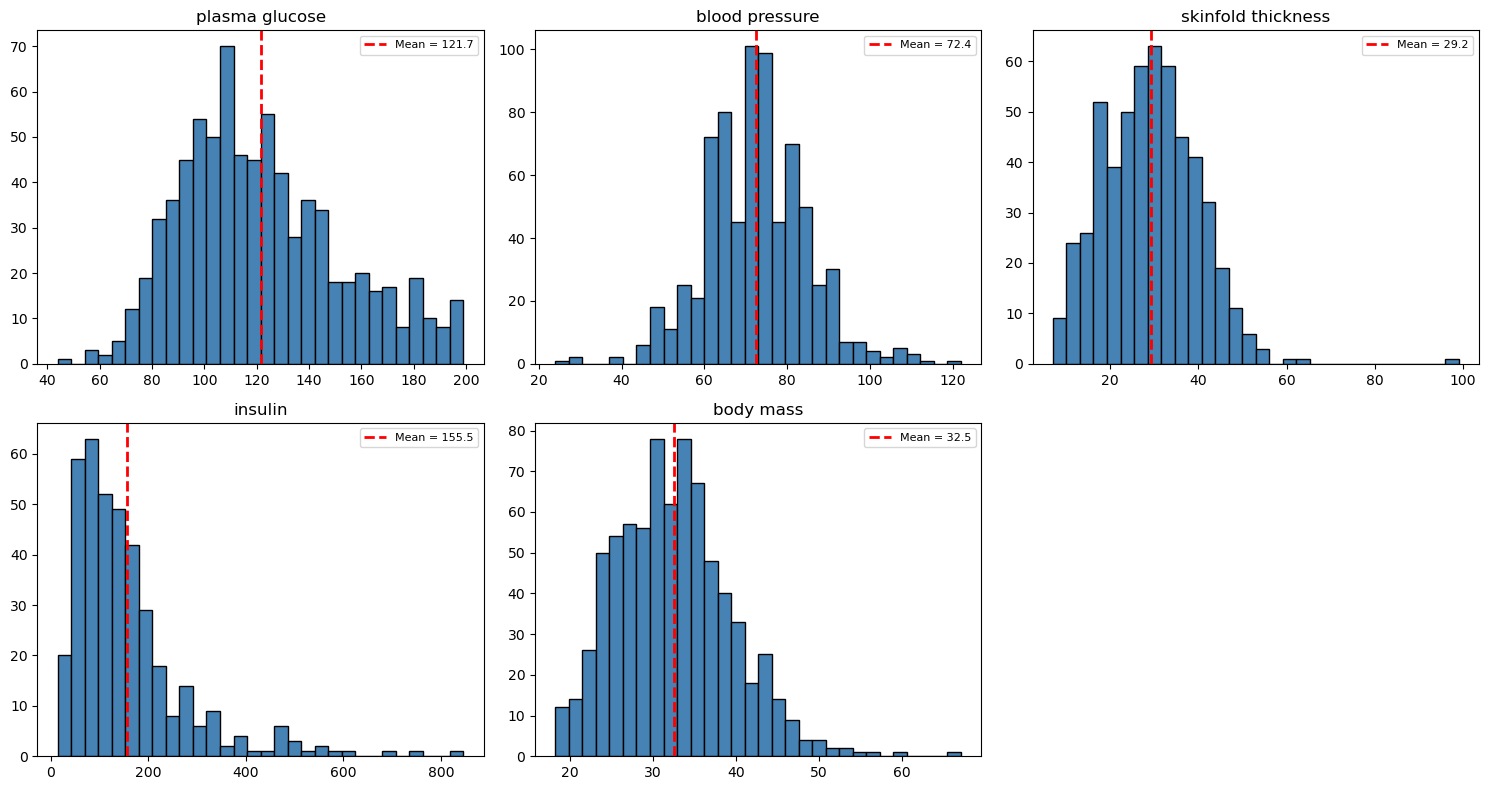

In [43]:
# Visualize the distribution of each column to decide mean or median is more appropriate.
# A skewed distribution (long tail) -> median is better.
# A roughly symmetric/normal distribution -> mean is fine.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_with_invalid_zeros):
    valid_values = df1[df1[col] != 0][col]
    
    axes[i].hist(valid_values, bins=30, color="steelblue", edgecolor="black")
    axes[i].axvline(valid_values.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {valid_values.mean():.1f}")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide the unused 6th subplot
axes[5].axis("off")

plt.tight_layout()
plt.show()

only (Insulin) is clearly skewed and it has a long right tail. The other columns are symmetric, so using the mean for them is appropriate and for (insuline) we use median.</br>
when a distribution is skewed, the mean can be distorted by outliers and become misleading

In [44]:
df2 = df1.copy()

In [45]:
mean_cols = ["plasma glucose", "blood pressure", "skinfold thickness", "body mass"]
median_cols = ["insulin"]

In [46]:
# replace columns using the mean
for col in mean_cols:
    calculate_mean = df2[df2[col] != 0][col].mean()
    df2[col] = df2[col].replace(0, calculate_mean)
    print(f"{col}: replaced zeros with (mean) = {calculate_mean:.2f}")

# replace columns using the median
for col in median_cols:
    calculate_median = df2[df2[col] != 0][col].median()
    df2[col] = df2[col].replace(0, calculate_median)
    print(f"{col}: replaced zeros with (median) = {calculate_median:.2f}")

plasma glucose: replaced zeros with (mean) = 121.69
blood pressure: replaced zeros with (mean) = 72.41
skinfold thickness: replaced zeros with (mean) = 29.15
body mass: replaced zeros with (mean) = 32.46
insulin: replaced zeros with (median) = 125.00


In [47]:
print((df2[cols_with_invalid_zeros] == 0).sum())

plasma glucose        0
blood pressure        0
skinfold thickness    0
insulin               0
body mass             0
dtype: int64


In [49]:
list(df2.columns)

['pregnancies',
 'plasma glucose',
 'blood pressure',
 'skinfold thickness',
 'insulin',
 'body mass',
 'diabetes pedigree',
 'age',
 'diabetic']

<h1 id="1" style="font-family:verdana;"> 
    <center>4.Plotting outliers 🎖
    </center>
</h1>

In [50]:
features = ["pregnancies", "plasma glucose", "blood pressure",
                 "skinfold thickness", "insulin", "body mass",
                 "diabetes pedigree", "age"]

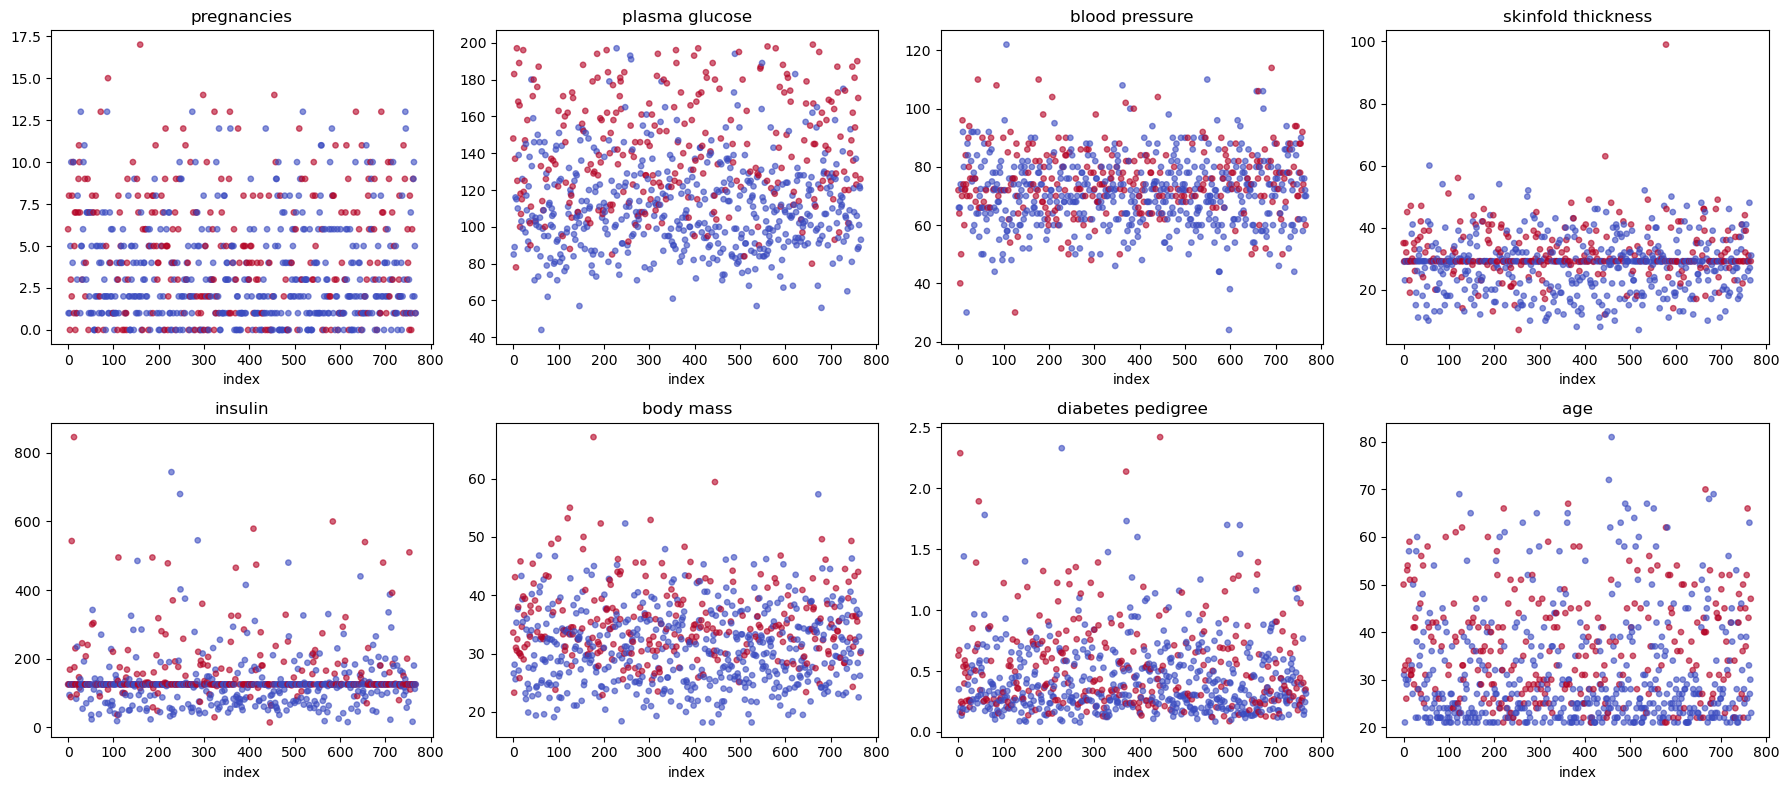

In [51]:
# Scatter plots to find outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    scatter = axes[i].scatter(
        df2.index, df2[col],
        c=df2["diabetic"], cmap="coolwarm", alpha=0.6, s=15
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("index")

plt.tight_layout()
plt.show()

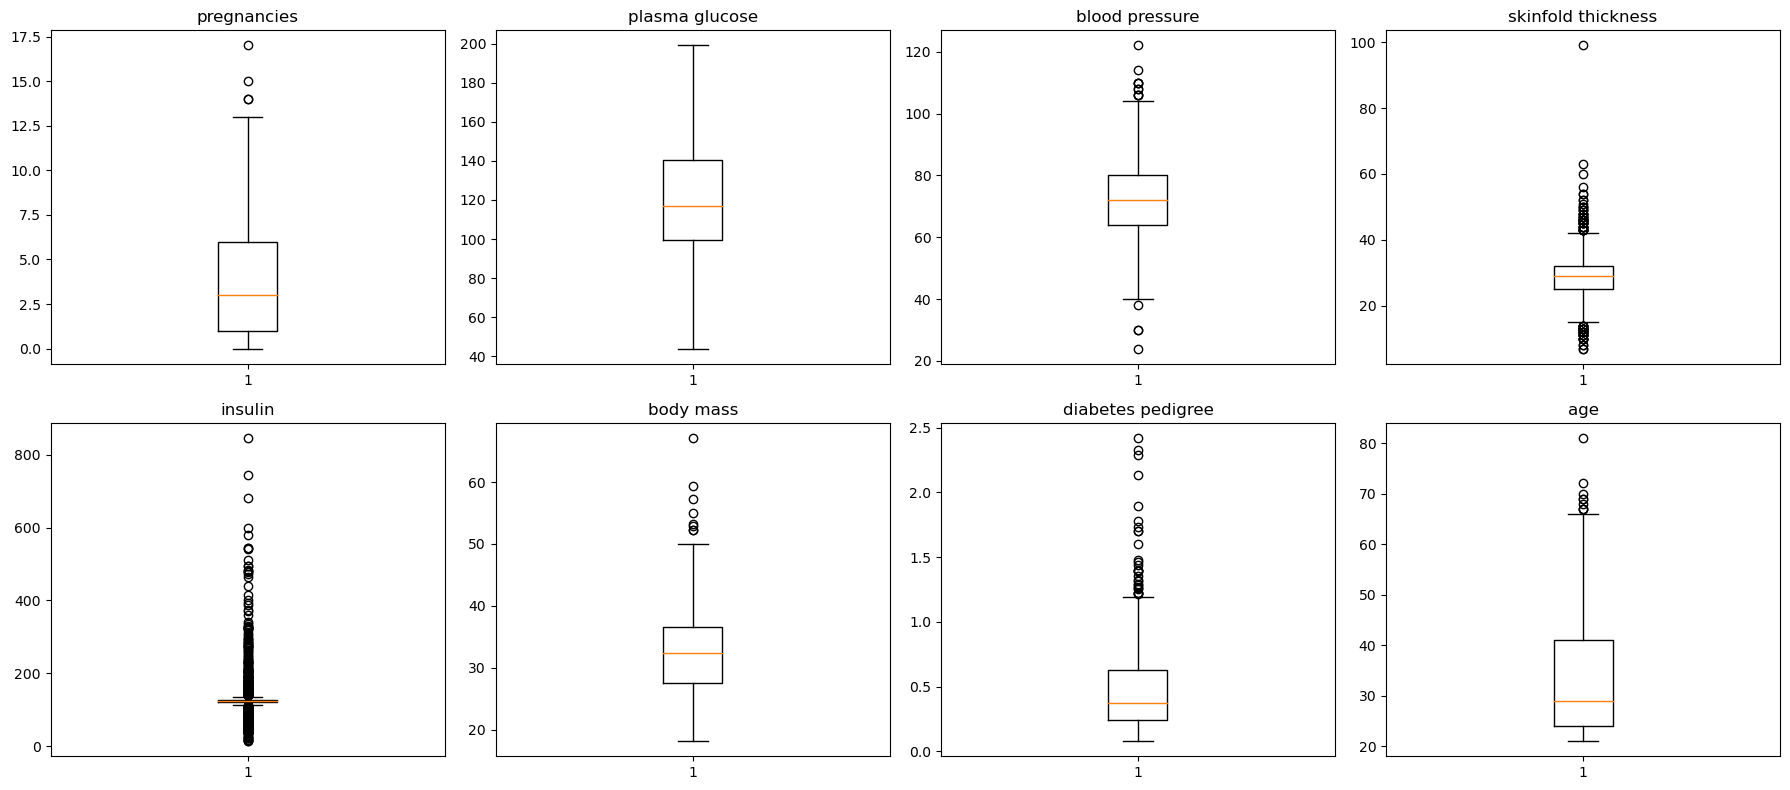

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df2[col], vert=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Outlier Analysis Summary

| Feature | Box Plot Observation | Is it a valid outlier? |
|---|---|---|
| **pregnancies** | A few points above 13 (up to 17) | ✅ Valid — a high number of pregnancies (15–17) is rare but physiologically possible |
| **plasma glucose** | No outliers shown) | ✅ No issue |
| **blood pressure** | A few points below 40 and a few above 105 | ⚠️ Low values (near 20–30) are suspicious — a diastolic blood pressure of 20–30 is nearly impossible for a living person |
| **skinfold thickness** | Many outliers close to 100 | ⚠️ A value of 99–100 is clearly unusual (triceps skinfold thickness is typically below 50mm) |
| **insulin** | Many outliers above 800 | ⚠️ Very high values (600–846) are rare but medically possible (severe insulin resistance) — should be treated with caution |
| **body mass** | A few outliers above 50 (up to nearly 70) | ⚠️ A BMI above 60–70 is very rare but **possible** (severe clinical obesity) |
| **diabetes pedigree** | A few outliers above 1.2 | ✅ This is a statistical index, not a direct physical measurement — values of 1.5–2.4 naturally occur |
| **age** | No outliers shown | ✅ No issue |

### Conclusion

Most of these "outliers" are statistically far from the mean but medically rare and real, not data errors. For example, a woman can genuinely have had 17 pregnancies, a diabetic patient can genuinely have insulin levels above 600 (insulin resistance), and a BMI above 50 is rare but seen in severely diabetic patients.

The only genuinely suspicious case is **blood pressure**, with values near 20–30 — this could represent unrecorded/missing data encoded as a small number rather than zero. 

**Decision:** These outliers will **not be removed** I just remove blood pressure <30:

1. Models like Random Forest and Decision Tree are relatively robust to outliers
2. Removing genuine medical outliers could introduce bias (e.g., excluding severely diabetic patients)

In [53]:
blood_pressure_noise = df2[df2['blood pressure']<35]
blood_pressure_noise

,pregnancies,plasma glucose,blood pressure,skinfold thickness,insulin,body mass,diabetes pedigree,age,diabetic
18,1,103.0,30.0,38.0,83,43.3,0.183,33,0
125,1,88.0,30.0,42.0,99,55.0,0.496,26,1
597,1,89.0,24.0,19.0,25,27.8,0.559,21,0


In [54]:
df2.drop(index=[597, 125, 18], inplace=True)

In [62]:
# df2 shape (768-3 = 765) ?
print(f"Shape of df2: {df2.shape}")

Shape of df2: (765, 9)


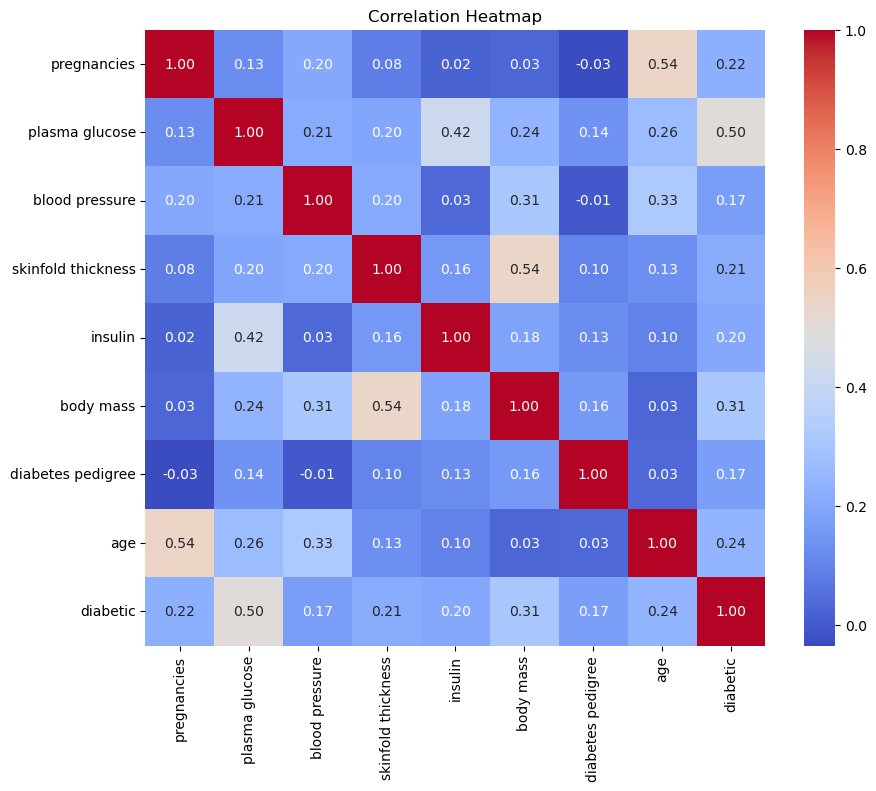

In [57]:
corr = df2.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()


<h1 id="1" style="font-family:verdana;"> 
    <center>5.Modelling 🎖
    </center>
</h1>

In [68]:
X = df2.drop(columns=["diabetic"])
y = df2["diabetic"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (765, 8)
y shape: (765,)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 42, stratify=y)

In [73]:
# Standardize features
# This is important for distance-based models like KNN and SVM,

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")

X_train_scaled shape: (612, 8)


In [75]:
# Train a Logistic Regression model
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [78]:
# Make predictions on the test set
y_pred_log_reg = logreg.predict(X_test_scaled)

In [80]:
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy: {acc_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_log_reg))

Accuracy: 0.7386
F1-Score: 0.5455

Detailed classification report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.82       100
           1       0.69      0.45      0.55        53

    accuracy                           0.74       153
   macro avg       0.72      0.67      0.68       153
weighted avg       0.73      0.74      0.72       153



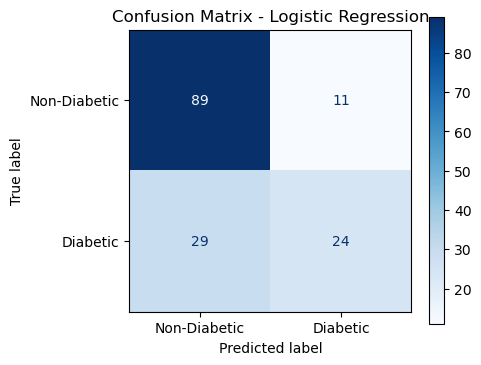

In [82]:
#confusion matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

# DecisionTree

In [84]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_scaled, y_train)


DecisionTreeClassifier(random_state=42)

In [85]:
y_pred_tree = tree_clf.predict(X_test_scaled)

In [86]:
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print(f"Accuracy: {acc_tree:.4f}")
print(f"F1-Score: {f1_tree:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.7059
F1-Score: 0.5631

Detailed classification report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.58      0.55      0.56        53

    accuracy                           0.71       153
   macro avg       0.67      0.67      0.67       153
weighted avg       0.70      0.71      0.70       153



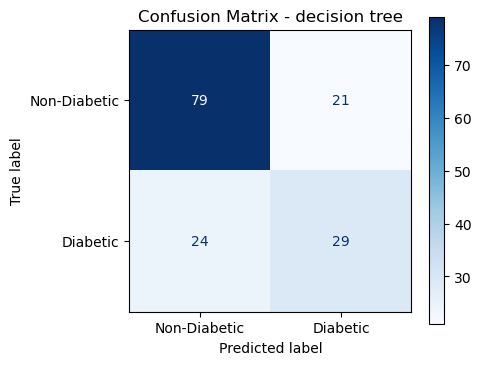

In [87]:
#confusion matrix for decision tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - decision tree")
plt.tight_layout()
plt.show()

# random forest

In [89]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [90]:
y_pred_rf = rf_clf.predict(X_test_scaled)


In [91]:
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7124
F1-Score: 0.5686

Detailed classification report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       100
           1       0.59      0.55      0.57        53

    accuracy                           0.71       153
   macro avg       0.68      0.67      0.68       153
weighted avg       0.71      0.71      0.71       153



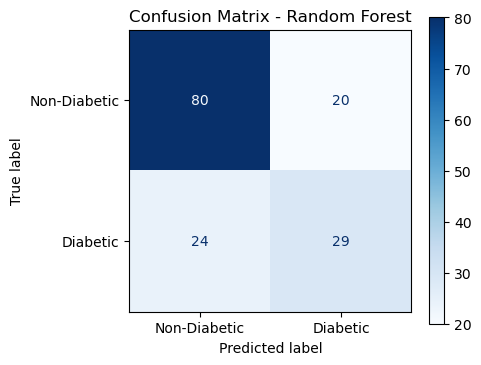

In [92]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

# knn

In [94]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [95]:
y_pred_knn = knn_clf.predict(X_test_scaled)

In [96]:
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {acc_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.6928
F1-Score: 0.5524

Detailed classification report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77       100
           1       0.56      0.55      0.55        53

    accuracy                           0.69       153
   macro avg       0.66      0.66      0.66       153
weighted avg       0.69      0.69      0.69       153



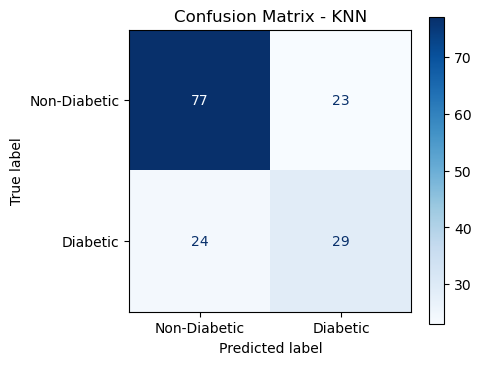

In [97]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - KNN")
plt.tight_layout()
plt.show()

# svm

In [99]:
svm_clf = SVC(kernel="rbf", random_state=42, probability=True)
svm_clf.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [100]:
y_pred_svm = svm_clf.predict(X_test_scaled)

In [101]:
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy: {acc_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7190
F1-Score: 0.5474

Detailed classification report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       100
           1       0.62      0.49      0.55        53

    accuracy                           0.72       153
   macro avg       0.69      0.67      0.67       153
weighted avg       0.71      0.72      0.71       153



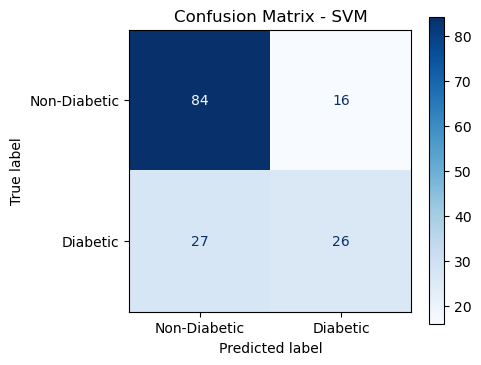

In [102]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - SVM")
plt.tight_layout()
plt.show()

# naive baise

In [104]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

GaussianNB()

In [105]:
y_pred_nb = nb_clf.predict(X_test_scaled)

In [106]:
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"Accuracy: {acc_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print()
print("Detailed classification report:")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.7124
F1-Score: 0.5417

Detailed classification report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       100
           1       0.60      0.49      0.54        53

    accuracy                           0.71       153
   macro avg       0.68      0.66      0.67       153
weighted avg       0.70      0.71      0.70       153

